In [1]:
import sys
!{sys.executable} -m pip install ipywidgets jupyterlab_widgets

In [30]:
%matplotlib widget

['L0_0', 'L1_10', 'L2_5', 'L3_0', 'L4_1', 'L5_1', 'L6_0', 'L7_1', 'L8_0', 'L9_0']
{'L0_0': ['L0_0'], 'L1_10': ['L1_10', 'L1_6', 'L1_0', 'L1_5', 'L1_8', 'L1_1', 'L1_4', 'L1_7', 'L1_9', 'L1_2', 'L1_3'], 'L2_5': ['L2_5', 'L2_1', 'L2_3', 'L2_0', 'L2_2', 'L2_4', 'L2_6'], 'L3_0': ['L3_0', 'L3_2', 'L3_1'], 'L4_1': ['L4_1', 'L4_0', 'L4_2'], 'L5_1': ['L5_1', 'L5_2', 'L5_0'], 'L6_0': ['L6_0', 'L6_2', 'L6_1'], 'L7_1': ['L7_1', 'L7_2', 'L7_0'], 'L8_0': ['L8_0'], 'L9_0': ['L9_0']}
[np.str_('axon'), np.str_('axon-like')]
[np.str_('basal')]
[np.str_('apical'), np.str_('apical_shaft')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[515155.6 682080.1 955987.7]
['L0_12', 'L1_27', 'L2_2', 'L3_0', 'L4_0', 'L5_0']
{'L0_12': ['L0_12', 'L0_11', 'L0_3', 'L0_4', 'L0_17', 'L0_8', 'L0_2', 'L0_18', 'L0_16', 'L0_9', 'L0_7', 'L0_5', 'L0_1', 'L0_6', 'L0_10', 'L0_15', 'L0_14', 'L0_0', 'L0_13'], 'L1_27': ['L1_27', 'L1_26', 'L1_11', 

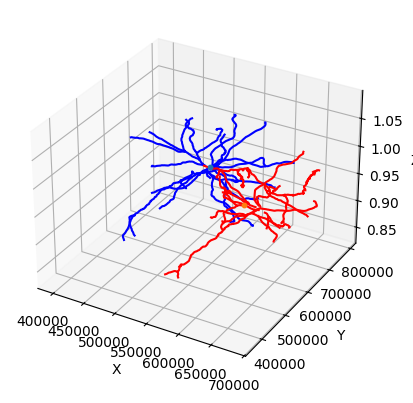

In [2]:
import bz2
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
import sys
from mpl_toolkits.mplot3d import Axes3D  # required for 3D

neuron_list = [864691135660612336, 864691136040985430] #List of neuron ids
with open("../data/skeletonization_data_simple.pkl", "rb") as f:
    skel_data = pickle.load(f)
# Unpack points

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

final_skeletonization_dict = {}

#display neurons in neuron_list with different colors for each downstream branch off of soma
blue = True
for n in neuron_list:
    color = "blue" if blue else "red"
    blue = False
    path= "../data/graph_exports/" + str(n)+'_0_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']
                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)

        final_skeletonization_dict[n] = skeleton_dict
        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()
# --- overlay nearby dendrite/axon points in GREEN on EXISTING plot ---

from scipy.spatial import cKDTree

n1, n2 = neuron_list
radius = 1000

dendrite = np.asarray(skel_data[str(n1)+"_0"]["dendrite"])
axon = np.asarray(skel_data[str(n2)+"_0"]["axon"])

d_tree = cKDTree(dendrite)
a_tree = cKDTree(axon)

d_idx = [i for i, hits in enumerate(d_tree.query_ball_tree(a_tree, r=radius)) if hits]
a_idx = [i for i, hits in enumerate(a_tree.query_ball_tree(d_tree, r=radius)) if hits]

if d_idx:
    pts = dendrite[d_idx]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c="green", s=2)

if a_idx:
    pts = axon[a_idx]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c="green", s=2)


['L0_18', 'L1_4', 'L2_0', 'L3_2', 'L4_2', 'L5_0']
{'L0_18': ['L0_18', 'L0_5', 'L0_8', 'L0_1', 'L0_0', 'L0_2', 'L0_12', 'L0_13', 'L0_9', 'L0_16', 'L0_3', 'L0_17', 'L0_6', 'L0_4', 'L0_15', 'L0_11', 'L0_14', 'L0_10', 'L0_7'], 'L1_4': ['L1_4', 'L1_1', 'L1_6', 'L1_5', 'L1_0', 'L1_2', 'L1_3'], 'L2_0': ['L2_0', 'L2_3', 'L2_1', 'L2_2', 'L2_4'], 'L3_2': ['L3_2', 'L3_1', 'L3_0'], 'L4_2': ['L4_2', 'L4_0', 'L4_1'], 'L5_0': ['L5_0', 'L5_1', 'L5_2']}
[np.str_('apical'), np.str_('apical_shaft')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('axon'), np.str_('axon-like')]
[503777. 955642. 752564.]
['L0_0', 'L1_0']
{'L0_0': ['L0_0'], 'L1_0': ['L1_0', 'L1_1', 'L1_2']}
[np.str_('axon'), np.str_('axon-like')]
[np.str_('basal')]
[ 601731.2 1091488.   873402.6]
2277


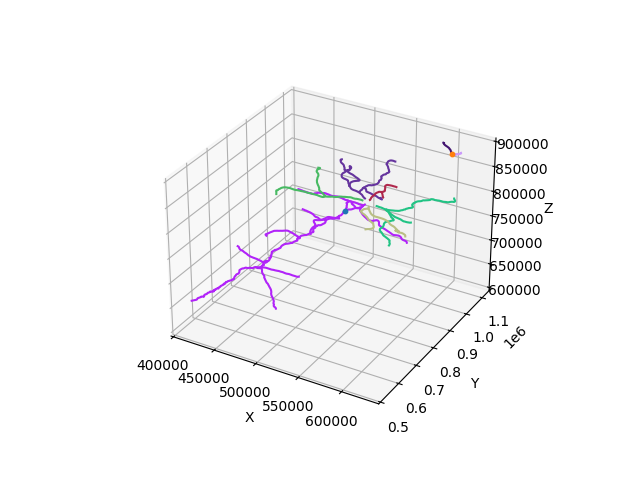

In [ ]:
#Visualize Neuron with two split ids

neuron_list = [864691135212606592] #id of neuron with two splits

# Unpack points

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


for n in neuron_list:
    path = "data/graph_exports/" + str(n)+'_0_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        #print(G.edges)
        
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            #print(downstream_connections)
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']

                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

for n in neuron_list:
    path= "data/graph_exports/" + str(n)+'_1_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']

                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)

        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

S0 L0_7 None
S0 L1_0 None
S0 L2_2 None
S0 L3_0 None
S0 L4_0 None
S0 L5_0 None
S0 L6_0 None
L0_7 L0_6 None
L0_7 L0_8 None
L0_6 L0_1 None
L0_6 L0_4 None
L0_4 L0_3 None
L0_4 L0_5 None
L0_3 L0_0 None
L0_3 L0_2 None
L1_0 L1_1 None
L1_0 L1_2 None
L2_2 L2_0 None
L2_2 L2_1 None
L3_0 L3_1 None
L3_0 L3_2 None
L3_2 L3_3 None
L3_2 L3_4 None
L3_4 L3_5 None
L3_4 L3_6 None
L3_6 L3_7 None
L3_6 L3_9 None
L3_9 L3_10 None
L3_9 L3_12 None
L3_9 L3_13 None
L3_9 L3_14 None
L3_9 L3_15 None
L3_13 L3_8 None
L3_13 L3_11 None
L3_15 L3_16 None
L3_15 L3_17 None
L3_17 L3_18 None
L3_17 L3_19 None
L3_19 L3_20 None
L3_19 L3_21 None
L3_21 L3_22 None
L3_21 L3_23 None
['L0_7', 'L1_0', 'L2_2', 'L3_0', 'L4_0', 'L5_0', 'L6_0']
{'L0_7': ['L0_7', 'L0_5', 'L0_3', 'L0_0', 'L0_2', 'L0_8', 'L0_1', 'L0_4', 'L0_6'], 'L1_0': ['L1_0', 'L1_1', 'L1_2'], 'L2_2': ['L2_2', 'L2_1', 'L2_0'], 'L3_0': ['L3_0', 'L3_10', 'L3_6', 'L3_8', 'L3_4', 'L3_3', 'L3_7', 'L3_18', 'L3_19', 'L3_23', 'L3_21', 'L3_13', 'L3_15', 'L3_11', 'L3_14', 'L3_17', 'L3_1

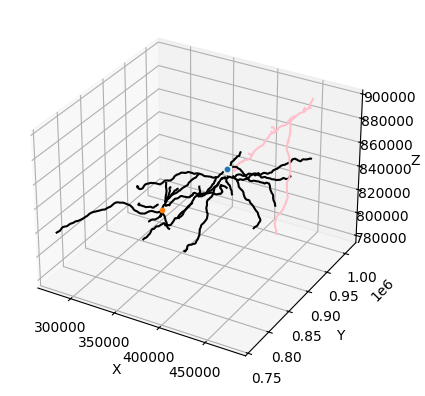

In [4]:
#Visualize Neuron with two split ids

color_dict = {"basal":"red","oblique":"orange","apical":"yellow","apical_shaft":"green","apical_tuft":"blue","dendrite":"black", "axon":"pink"}

neuron_list = [864691135207754617,864691136594524834] #id of neuron with two splits

# Unpack points

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for n in neuron_list:
    path = "../data/graph_exports/" + str(n)+'_0_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        for u, v, w in G.edges(data="weight"):
            print(u, v, w)

        
                
        final_branch_dict={}
        
        first_child_list=[]
        #print(G.edges)
        
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            #print(downstream_connections)
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))
        for node in G:
            if "axon_compartment" in G_dict[node]:
                print(node, G_dict[node]["compartment"])

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            compartment = G_dict[node]['compartment']
            axon_compartment = G_dict[node]['axon_compartment']
            print(f"compartment: {axon_compartment}")
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']

                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color_dict[axon_compartment])
                # if node_data['labels'][0]=="apical":
                #     ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color_dict[compartment])
                # elif node_data['labels'][0]=="basal":
                #     ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color_dict[compartment])
                # elif node_data['labels'][0]=="axon":
                #     ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color_dict[compartment])
        
        center = list(G.nodes(data=True))[0][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


In [11]:
print(color_dict["apical"])


yellow


In [43]:
with open("../data/synapses.json","r") as f:
    print(f.read(10000))

{"420651745": [[864691135502048693, 864691135547009778], {"upstream_dist": 10576.449248284789, "head_neck_shaft": "head", "syn_id": 420651745, "volume": 7916, "syn_type": "postsyn"}], "415707009": [[864691135502048693, 864691135547009778], {"upstream_dist": 84293.42616553586, "head_neck_shaft": "shaft", "syn_id": 415707009, "volume": 1664, "syn_type": "postsyn"}], "426241435": [[864691135472038450, 864691135547009778], {"upstream_dist": 3796.3198775111678, "head_neck_shaft": "shaft", "syn_id": 426241435, "volume": 4432, "syn_type": "postsyn"}], "435104183": [[864691135544605224, 864691135547009778], {"upstream_dist": 13099.855279603515, "head_neck_shaft": "head", "syn_id": 435104183, "volume": 2688, "syn_type": "postsyn"}], "455080278": [[864691135291753654, 864691135547009778], {"upstream_dist": 96095.83145155996, "head_neck_shaft": "neck", "syn_id": 455080278, "volume": 1608, "syn_type": "postsyn"}], "432877938": [[864691135989790154, 864691135547009778], {"upstream_dist": 7696.95826

In [3]:
with open("../data/skeletonization_data_simple.pkl", "rb") as f:
        skeletonization_data = pickle.load(f)
neuron = next(iter(skeletonization_data))
print(neuron)
print(skeletonization_data["864691135334559465_0"])
print(skeletonization_data)

864691135334559465_0
{'axon': array([[1129170.        ,  748946.        ,  919267.        ],
       [1129157.72486272,  748954.02908039,  919261.44903084],
       [1128375.02448982,  749465.98785307,  918907.50222504],
       [1128363.17922367,  750378.30556235,  918852.12843544],
       [1128582.        ,  751275.        ,  918582.        ],
       [1128582.        ,  751275.        ,  918582.        ],
       [1128460.01946981,  751279.02414559,  918704.48618011],
       [1128457.96328742,  751445.74241769,  919555.76793524],
       [1128368.18118427,  752156.44771077,  919589.27965812],
       [1127944.        ,  753016.2       ,  919466.4       ],
       [1128582.        ,  751275.        ,  918582.        ],
       [1128724.08063414,  752213.45620668,  918611.93762247],
       [1128764.42437469,  753192.4746943 ,  918631.59173069],
       [1128639.42857345,  754125.65263757,  918860.12622181],
       [1128675.15047963,  755082.53720184,  918890.24162896],
       [1128975.81225282,

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
with open("../data/skeletonization_data_simple.pkl", "rb") as f:
        skel_data = pickle.load(f)
def count_dendrite_points_near_axon(
    skel_data,
    neuron1_id,
    neuron2_id,
    radius=5000,
):
    
    """
    Count how many dendrite points of neuron1
    are within `radius` of any axon point of neuron2,
    using query_ball_tree.
    """

    neuron1 = skel_data[neuron1_id]['dendrite']
    neuron2 = skel_data[neuron2_id]['axon']
    count = 0
    for d in neuron1:
        for a in neuron2:
            if np.linalg.norm(d-a)<=radius:
                count+=1
                break

    

    # count dendrite points that have at least one nearby axon point
    return count

import numpy as np
from scipy.spatial import cKDTree

def dendrite_axon_points_within_radius(
    skel_data,
    neuron1_id,
    neuron2_id,
    radius=5000,
):
    """
    Returns:
        dendrite_hits: (N, 3) numpy array of dendrite points
        axon_hits:     (M, 3) numpy array of axon points
    """

    dendrite = np.asarray(skel_data[neuron1_id]["dendrite"])
    axon = np.asarray(skel_data[neuron2_id]["axon"])

    dend_tree = cKDTree(dendrite)
    axon_tree = cKDTree(axon)

    # dendrite indices that are near ANY axon
    dend_idx_lists = dend_tree.query_ball_tree(axon_tree, r=radius)
    dend_indices = [i for i, hits in enumerate(dend_idx_lists) if hits]

    # axon indices that are near ANY dendrite
    axon_idx_lists = axon_tree.query_ball_tree(dend_tree, r=radius)
    axon_indices = [i for i, hits in enumerate(axon_idx_lists) if hits]

    dendrite_hits = dendrite[dend_indices]
    axon_hits = axon[axon_indices]

    return dendrite_hits, axon_hits


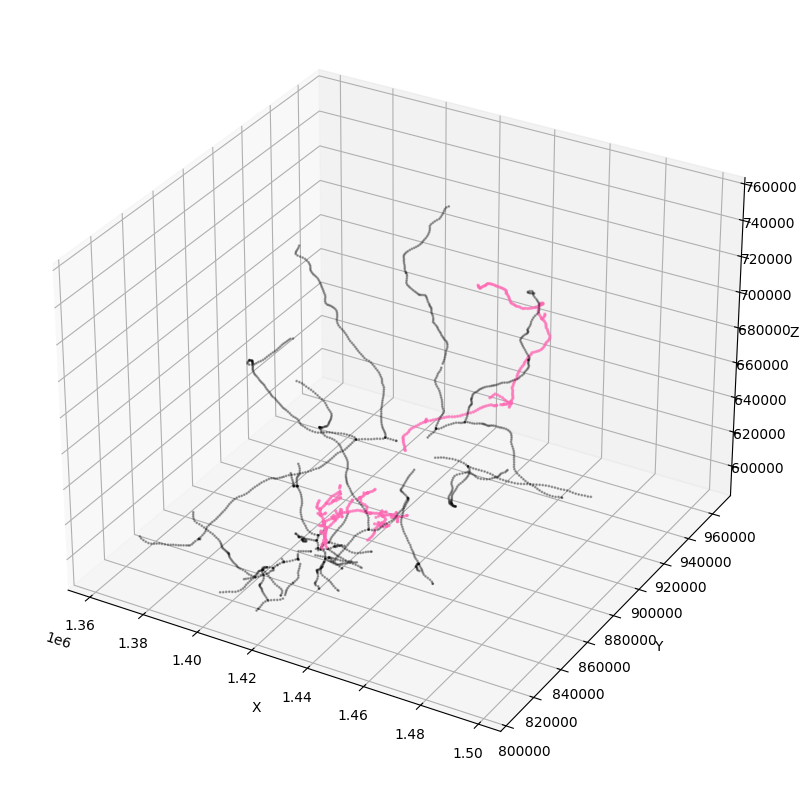

In [6]:
with open("../data/KD_tree_data_simple.pkl", "rb") as f:
        KD_tree_data = pickle.load(f)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

data = KD_tree_data["864691135334559465_0"]
print(data)

axon = data["axon"].data        # (Na, 3)
dendrite = data["dendrite"].data  # (Nd, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(dendrite[:,0], dendrite[:,1], dendrite[:,2],
           c="black", s=1, alpha=0.6)

ax.scatter(axon[:,0], axon[:,1], axon[:,2],
           c="hotpink", s=2, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


In [9]:
with open("../data/adp_data.pkl", "rb") as f:
    adp_data = pickle.load(f)
#Count how many dendrite points of neuron1
#are within `radius` (10 microns) of any axon point of neuron2,
#using query_ball_tree.

n_close = count_dendrite_points_near_axon(
    skel_data,
    "864691135334559465_0",
    "864691135888491657_0",
    radius=10000 #nanometers; 10 microns
)

#[864691135502048693, 864691135547009778]
print(f"Close dendrite points: {n_close}")

# adp_data[neuron_a][neuron_b] how many points (seperated by 1 micron) on the dendritic branches of neuron a
# are within 10 microns of the axonal branches of neuron b. Total values is in microns


# adp_data["864691135334559465_0"]["864691135888491657_0"] how many points (seperated by 1 micron) on 
# the dendritic branches of neuron "864691135334559465_0"
# are within 10 microns of the axonal branches of "864691135888491657_0". Total values is in microns
print(f"Close dendrite points via adp_data file: {adp_data["864691135334559465_0"]["864691135888491657_0"]}")

Close dendrite points: 237
Close dendrite points via adp_data file: 237


In [4]:
with open("../data/adp_data.pkl", "rb") as f:
    adp_data = pickle.load(f)
with open("../data/idx_to_neuron.pkl","rb") as f:
    idx_to_neuron = pickle.load(f)
i=0
# print(len(adp_data))
# print(adp_data["864691135502048693_0"]["864691135547009778_0"])
for i in adp_data:
    print(f"total number of neurons in adp_dict: {len(adp_data)}")
    print(f"total number of axons close to dendritic nueron: {len(adp_data[i])}")
    print(f"dendritic neuron id: {i}")
    x = adp_data[i]
    print(f"axonal proximites: {x}")
    i+=1
    if i >=1:
        break





total number of neurons in adp_dict: 68475
total number of axons close to dendritic nueron: 2835
dendritic neuron id: 864691135334559465_0
axonal proximites: {'864691135888491657_0': 237, '864691136123697702_0': 483, '864691135508879113_0': 746, '864691135758472014_0': 247, '864691135864406398_0': 402, '864691135865578629_0': 185, '864691136482925612_0': 364, '864691137019565934_0': 343, '864691135776948320_0': 573, '864691135256494255_0': 273, '864691136175368966_0': 185, '864691135012366326_0': 209, '864691135998122442_0': 537, '864691136867903598_0': 134, '864691135490489447_0': 161, '864691135855569454_0': 197, '864691135952033315_0': 239, '864691134988392826_0': 82, '864691135478316486_0': 385, '864691136041071190_0': 243, '864691135739595156_0': 448, '864691135850800327_0': 63, '864691135013134998_0': 937, '864691135718449713_0': 28, '864691135012872598_0': 297, '864691136050815475_0': 270, '864691135478272198_0': 289, '864691135736066452_0': 195, '864691136965794510_0': 197, '86

TypeError: can only concatenate str (not "int") to str

In [3]:
import os
import numpy as np

def is_synapse_id_in_neuron(neuron_id,synapse_id):
    path = os.path.join(graph_directory, str(neuron_id) + str("_auto_proof_v7_proofread.pbz2"))
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)

    fname = os.path.basename(path)
    G_dict = dict(list(G.nodes(data=True)))
    i=0
    for node in G_dict:
        attr = G_dict[node]
        
        if "synapse_data" not in attr:
            continue
        syn_data = attr['synapse_data']
        
        for synapse in syn_data:
            if bool(synapse_id==synapse['syn_id']):
                return True
    return False

In [2]:
import random
import json
import bz2
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
import sys
import os
from mpl_toolkits.mplot3d import Axes3D  # required for 3D
with open("../data/adp_data.pkl", "rb") as f:
    adp_data = pickle.load(f)
with open("../data/synapses.json", "r", encoding="utf-8") as f:
    synapse_data = json.load(f)
with open("../data/idx_to_neuron.pkl","rb") as f:
    idx_to_neuron = pickle.load(f)
keys = list(adp_data.keys())
synapse_keys = list(synapse_data.keys())

synapse_items = list(synapse_data.items())

synaptic_vals = []
random_vals = []

graph_directory = "../data/graph_exports"
files = [f for f in os.listdir(graph_directory)
         if os.path.isfile(os.path.join(graph_directory, f))]

print(files[0:10])

['864691135334559465_0_auto_proof_v7_proofread.pbz2', '864691135502029237_0_auto_proof_v7_proofread.pbz2', '864691135994801578_0_auto_proof_v7_proofread.pbz2', '864691135765700541_0_auto_proof_v7_proofread.pbz2', '864691135162192941_0_auto_proof_v7_proofread.pbz2', '864691135590146571_0_auto_proof_v7_proofread.pbz2', '864691135941191540_0_auto_proof_v7_proofread.pbz2', '864691135686914272_0_auto_proof_v7_proofread.pbz2', '864691135815480655_0_auto_proof_v7_proofread.pbz2', '864691135322941084_0_auto_proof_v7_proofread.pbz2']


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
Synaptic:
0 ADP: 100 (10.13%)
Non-zero ADP: 887 (89.87%)

Random:
0 ADP: 959 (97.16%)
Non-zero ADP: 28 (2.84%)


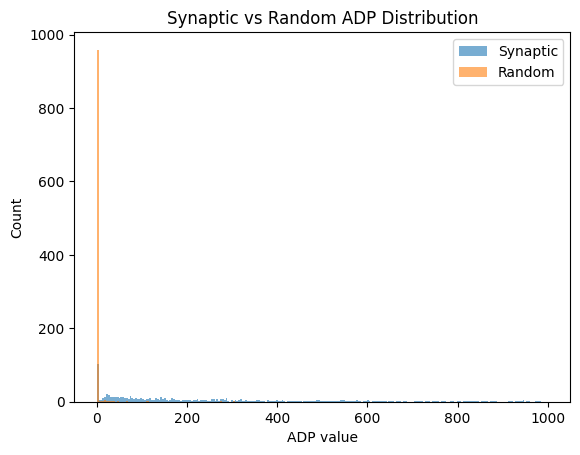

In [4]:

N = 1000  # or whatever is statistically solid

for _ in range(N):
    synapse_id = random.sample(synapse_keys,1)[0]

    random_key, random_value = random.sample(synapse_items,1)[0]

    random_synapse_id = int(random_key)
    
    synapse_string_1 = str(random_value[0][0]) + "_0"
    synapse_string_2 = str(random_value[0][1]) + "_0"

    if not (is_synapse_id_in_neuron(synapse_string_1,random_synapse_id) and is_synapse_id_in_neuron(synapse_string_2,random_synapse_id)):
        continue

    synaptic_ADP = 0

    # pick a real synaptic partner of k1
    if synapse_string_1 in adp_data:
        synaptic_ADP=adp_data[synapse_string_1].get(synapse_string_2,0)
    if synapse_string_2 in adp_data:
        synaptic_ADP=max(synaptic_ADP,adp_data[synapse_string_2].get(synapse_string_1,0))
    
    
    random_partner = random.choice(keys)
    if synapse_string_1 in adp_data:
        random_ADP = adp_data[synapse_string_1].get(random_partner, 0)
    elif synapse_string_2 in adp_data:
        random_ADP = adp_data[synapse_string_2].get(random_partner, 0)

    synaptic_vals.append(synaptic_ADP)
    random_vals.append(random_ADP)

    if _%10==0:
        print(_)
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(
    0,
    1000,
    250
)

# Synaptic percentages
synaptic_zero = sum(1 for v in synaptic_vals if v == 0)
synaptic_nonzero = sum(1 for v in synaptic_vals if v != 0)
synaptic_total = len(synaptic_vals)

# Random percentages
random_zero = sum(1 for v in random_vals if v == 0)
random_nonzero = sum(1 for v in random_vals if v != 0)
random_total = len(random_vals)

print("Synaptic:")
print(f"0 ADP: {synaptic_zero} ({100*synaptic_zero/synaptic_total:.2f}%)")
print(f"Non-zero ADP: {synaptic_nonzero} ({100*synaptic_nonzero/synaptic_total:.2f}%)")

print("\nRandom:")
print(f"0 ADP: {random_zero} ({100*random_zero/random_total:.2f}%)")
print(f"Non-zero ADP: {random_nonzero} ({100*random_nonzero/random_total:.2f}%)")

plt.hist(synaptic_vals, bins=bins, alpha=0.6, label="Synaptic")
plt.hist(random_vals, bins=bins, alpha=0.6, label="Random")

plt.xlabel("ADP value")
plt.ylabel("Count")
plt.legend()
plt.title("Synaptic vs Random ADP Distribution")
plt.show()


In [12]:
'864691135724583851_0': defaultdict(<class 'int'>, {'864691135269743781_0': 14, '864691135735865492_0': 14, '864691135510441680_0': 8, '864691135915347814_0': 6, '864691135213069112_0': 11, '864691135733631380_0': 41, '864691135581964653_0': 15, '864691135926335956_0': 58, '864691135654085570_0': 10, '864691136577527572_0': 11})

SyntaxError: illegal target for annotation (3873722638.py, line 1)

In [36]:
x = np.array([1,2,3])
y = np.array([4,5,6])
print(np.linalg.norm(x,y))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [4]:
import json

with open("../data/synapses.json", "r", encoding="utf-8") as f:
    synapse_data = json.load(f)

In [11]:
i=0
for i in synapse_data:
    print(i)
    print(synapse_data[i])
    break

420651745
[[864691135502048693, 864691135547009778], {'upstream_dist': 10576.449248284789, 'head_neck_shaft': 'head', 'syn_id': 420651745, 'volume': 7916, 'syn_type': 'postsyn'}]


In [14]:
synapse_keys = list(synapse_data.keys())

In [16]:
print(synapse_keys[0:10]
     )

['420651745', '415707009', '426241435', '435104183', '455080278', '432877938', '421781809', '420996969', '400034985', '89396566']


In [20]:
print(list(synapse_data.keys())[0:10])


['420651745', '415707009', '426241435', '435104183', '455080278', '432877938', '421781809', '420996969', '400034985', '89396566']


In [1]:
import os
graph_directory = "../data/graph_exports"

files = [f for f in os.listdir(graph_directory)
         if os.path.isfile(os.path.join(graph_directory, f))]

In [21]:
import os
import bz2
import pickle
graph_directory = "../data/graph_exports"

neuron_ids = [864691135502048693]
for n in neuron_ids:
    path = os.path.join(graph_directory, str(n) + str("_0_auto_proof_v7_proofread.pbz2"))
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)

    fname = os.path.basename(path)
    print(fname)
    G_dict = dict(list(G.nodes(data=True)))
    i=0
    for node in G_dict:
        attr = G_dict[node]
        
        if "synapse_data" not in attr:
            continue
        syn_data = attr['synapse_data']
        
        for synapse in syn_data:
            print(synapse['syn_id'])
        i+=1
        if i==2:
            break


864691135502048693_0_auto_proof_v7_proofread.pbz2
368310345
375180633
375181297
367818628


In [ ]:

with bz2.open(path, 'rb') as f:
    G = pickle.load(f)

In [17]:
import numpy as np
x=368310345
y= np.int64(368310345)

In [19]:
bool(y==x)

True

In [25]:
def is_synapse_id_in_neuron(neuron_id,synapse_id):
    path = os.path.join(graph_directory, str(neuron_id) + str("_0_auto_proof_v7_proofread.pbz2"))
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)

    fname = os.path.basename(path)
    G_dict = dict(list(G.nodes(data=True)))
    i=0
    for node in G_dict:
        attr = G_dict[node]
        
        if "synapse_data" not in attr:
            continue
        syn_data = attr['synapse_data']
        
        for synapse in syn_data:
            if bool(synapse_id==synapse['syn_id']):
                return True
    return False

In [28]:
is_synapse_id_in_neuron(864691135502048693,368310345)


True

In [23]:
print(list(synapse_data.items())[:10])



[('420651745', [[864691135502048693, 864691135547009778], {'upstream_dist': 10576.449248284789, 'head_neck_shaft': 'head', 'syn_id': 420651745, 'volume': 7916, 'syn_type': 'postsyn'}]), ('415707009', [[864691135502048693, 864691135547009778], {'upstream_dist': 84293.42616553586, 'head_neck_shaft': 'shaft', 'syn_id': 415707009, 'volume': 1664, 'syn_type': 'postsyn'}]), ('426241435', [[864691135472038450, 864691135547009778], {'upstream_dist': 3796.3198775111678, 'head_neck_shaft': 'shaft', 'syn_id': 426241435, 'volume': 4432, 'syn_type': 'postsyn'}]), ('435104183', [[864691135544605224, 864691135547009778], {'upstream_dist': 13099.855279603515, 'head_neck_shaft': 'head', 'syn_id': 435104183, 'volume': 2688, 'syn_type': 'postsyn'}]), ('455080278', [[864691135291753654, 864691135547009778], {'upstream_dist': 96095.83145155996, 'head_neck_shaft': 'neck', 'syn_id': 455080278, 'volume': 1608, 'syn_type': 'postsyn'}]), ('432877938', [[864691135989790154, 864691135547009778], {'upstream_dist':

In [29]:
print(synapse_data['169384835'])

[[864691135256399279, 864691135341459377], {'upstream_dist': 13443.00700564813, 'head_neck_shaft': 'non_bouton', 'syn_id': 169384835, 'volume': 2684, 'syn_type': 'presyn'}]


In [ ]:
864691135256399279_0
864691135341459377_0
169384835


In [36]:
is_synapse_id_in_neuron("864691135256399279_0",169384835)

True

In [45]:
min_key = min(adp_data, key=lambda k: min(adp_data[k].values()))
min_value = min(adp_data[min_key].values())

print(min_key, min_value)

864691135334559465_0 1


In [9]:
import os
import bz2
import pickle
import numpy as np

all_widths = []

for n in neuron_ids:
    path = os.path.join(graph_directory, str(n) + "_0_auto_proof_v7_proofread.pbz2")

    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)

    print(os.path.basename(path))

    for node, attr in G.nodes(data=True):
        if 'width_data' in attr:
            width_list = attr['width_data']

            for entry in width_list:
                all_widths.append(float(entry['width']))

# Convert to numpy array
all_widths = np.array(all_widths)

print("\n===== GLOBAL WIDTH STATS =====")
print("Total samples:", len(all_widths))
print("Mean width:", np.mean(all_widths))
print("Median width:", np.median(all_widths))
print("Max width:", np.max(all_widths))
print("Min width:", np.min(all_widths))
print("Std deviation:", np.std(all_widths))

864691135502048693_0_auto_proof_v7_proofread.pbz2

===== GLOBAL WIDTH STATS =====
Total samples: 5544
Mean width: 296.8741948672008
Median width: 293.3762695038247
Max width: 1783.7144204797135
Min width: 4.116783163865146
Std deviation: 164.46211877990302


In [20]:
def width_stats(neuron_directory, limit=100):
    import os
    import bz2
    import pickle
    import numpy as np
    import time

    files = sorted([
        f for f in os.listdir(neuron_directory)
        if os.path.isfile(os.path.join(neuron_directory, f))
    ])

    files = files[:limit]

    print(f"Processing {len(files)} neurons\n")

    all_widths = []
    neurons_processed = 0
    start = time.time()

    for i, file in enumerate(files, start=1):

        path = os.path.join(neuron_directory, file)

        with bz2.open(path, 'rb') as f:
            G = pickle.load(f)

        for _, attr in G.nodes(data=True):
            if 'width_data' in attr:
                for entry in attr['width_data']:
                    all_widths.append(float(entry['width']))

        neurons_processed += 1

        if i % 100 == 0:
            print(f"Processed {i} neurons")

    all_widths = np.array(all_widths)

    print("\n===== WIDTH STATS =====")
    print(f"Neurons processed: {neurons_processed}")
    print(f"Total width samples: {len(all_widths)}")
    print(f"Mean width: {np.mean(all_widths):.3f}")
    print(f"Median width: {np.median(all_widths):.3f}")
    print(f"Max width: {np.max(all_widths):.3f}")
    print(f"Min width: {np.min(all_widths):.3f}")
    print(f"Std deviation: {np.std(all_widths):.3f}")
    print(f"95th percentile: {np.percentile(all_widths, 95):.3f}")
    print(f"99th percentile: {np.percentile(all_widths, 99):.3f}")
    print(f"Runtime: {time.time() - start:.2f} sec")

In [21]:
width_stats("../data/graph_exports")

Processing 100 neurons

Processed 100 neurons

===== WIDTH STATS =====
Neurons processed: 100
Total width samples: 545
Mean width: 402.613
Median width: 280.498
Max width: 2457.676
Min width: 4.175
Std deviation: 394.723
95th percentile: 1334.036
99th percentile: 1985.817
Runtime: 0.07 sec


In [24]:
import os
import bz2
import pickle
import numpy as np

all_widths = []

for n in neuron_ids:
    path = os.path.join(graph_directory, str(n) + "_0_auto_proof_v7_proofread.pbz2")

    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)

    print(os.path.basename(path))

    G_dict = dict(G.nodes(data=True))

    for node, attr in G_dict.items():
        print(attr)

# Convert to numpy for stats


864691135502048693_0_auto_proof_v7_proofread.pbz2
{'area': np.float64(714.2604810080288), 'compartment': 'soma', 'mesh_center': array([1261903.34861375,  923260.62158754,  683109.64116597]), 'endpoint_upstream': array([1261903.34861375,  923260.62158754,  683109.64116597]), 'n_synapses': 477, 'n_synapses_post': 476, 'n_synapses_pre': 1, 'sdf': np.float64(0.752), 'side_length_ratios': [1.061123500679534, 1.0382332770957026, 1.0220472836777716], 'volume_ratio': np.float64(4.951912456061076), 'mesh_volume': np.float64(1.1957050966746463e-42)}
{'area': np.float64(74.51231651685174), 'compartment': 'axon', 'axon_compartment': 'axon', 'boutons_cdfs': None, 'boutons_volume': None, 'labels': ['axon-like', 'axon'], 'mesh_center': array([1209238.0044428 ,  879527.65534987,  662526.9503147 ]), 'endpoint_upstream': array([1231809. ,  878028.2,  677507.6]), 'endpoint_downstream': array([1190140. ,  873833.8,  645078.9]), 'mesh_volume': np.float64(453.86216937286974), 'n_boutons': 0, 'n_spines': 0, 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

